# Interactive Quickshift Explained
This notebook implements Quickshift from scratch, illustrating each step:
1. Density estimation
2. Graph construction
3. Connected components → superpixels
Adjust hyperparameters interactively to see their effect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, transform, color
import networkx as nx
import ipywidgets as widgets
from ipywidgets import interact, fixed
%matplotlib inline

(-0.5, 199.5, 199.5, -0.5)

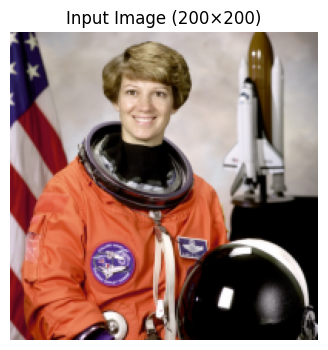

In [2]:
# Load sample image and downsample for speed
orig = img_as_float(data.astronaut())  # replace with any image
img = transform.resize(orig, (200, 200), anti_aliasing=True)
H, W, _ = img.shape
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title('Input Image (200×200)')
plt.axis('off')

In [3]:
def compute_density(img, kw, ks, sigma0=1e-5):
    H, W, _ = img.shape
    P = np.zeros((H, W))
    for i in range(H):
        for j in range(W):
            # window bounds
            i0, i1 = max(0, i-kw), min(H, i+kw+1)
            j0, j1 = max(0, j-kw), min(W, j+kw+1)
            patch = img[i0:i1, j0:j1]
            coords = np.indices(patch.shape[:2]).transpose(1,2,0)
            # spatial distances
            di = coords[:,:,0] + i0 - i
            dj = coords[:,:,1] + j0 - j
            spatial_sq = di**2 + dj**2
            # color distances
            diff = patch - img[i,j]
            color_sq = np.sum(diff**2, axis=2)
            # kernel
            w = np.exp(-(spatial_sq + color_sq) / (2*ks*ks))
            P[i,j] = w.sum() + np.random.randn()*sigma0
    return P

In [4]:
def quickshift_custom(img, kw=15, ks=5, dm=10):
    H, W, _ = img.shape
    P = compute_density(img, kw, ks)
    G = nx.DiGraph()
    # add nodes
    for i in range(H):
        for j in range(W):
            G.add_node((i,j))
    # add edges
    for i in range(H):
        for j in range(W):
            i0, i1 = max(0, i-kw), min(H, i+kw+1)
            j0, j1 = max(0, j-kw), min(W, j+kw+1)
            best = None
            best_dist = None
            for u in range(i0, i1):
                for v in range(j0, j1):
                    if P[u,v] > P[i,j]:
                        d = (i-u)**2 + (j-v)**2 + np.sum((img[i,j]-img[u,v])**2)
                        if best is None or d < best_dist:
                            best, best_dist = (u,v), d
            # add directed edge if exists and within max_dist
            if best is not None and np.sqrt(best_dist) <= dm:
                G.add_edge((i,j), best)
    # undirected connectivity → superpixels
    comp = list(nx.weakly_connected_components(G))
    label_map = np.zeros((H, W), dtype=int)
    for idx, c in enumerate(comp):
        for (i,j) in c:
            label_map[i,j] = idx
    return P, label_map

In [5]:
def display_quickshift(kw, ks, dm):
    P, labels = quickshift_custom(img, kw, ks, dm)
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    ax[0].imshow(img)
    ax[0].set_title('Original')
    ax[0].axis('off')
    # density map
    im1 = ax[1].imshow(P, cmap='viridis')
    ax[1].set_title('Density P')
    ax[1].axis('off')
    plt.colorbar(im1, ax=ax[1], fraction=0.046)
    # segmentation boundaries
    boundaries = color.label2rgb(labels, img, kind='overlay')
    ax[2].imshow(boundaries)
    ax[2].set_title('Quickshift Superpixels')
    ax[2].axis('off')
    plt.show()

In [6]:
interact(
    display_quickshift,
    kw=widgets.IntSlider(min=5, max=30, step=5, value=15, description='kernel_width'),
    ks=widgets.IntSlider(min=1, max=15, step=1, value=5, description='kernel_size'),
    dm=widgets.IntSlider(min=1, max=30, step=1, value=10, description='max_dist')
)

interactive(children=(IntSlider(value=15, description='kernel_width', max=30, min=5, step=5), IntSlider(value=…

<function __main__.display_quickshift(kw, ks, dm)>